# Exploratory Data Analysis (EDA)

## 1. Objetivo del análisis

En sistemas de Retrieval-Augmented Generation (RAG), la fase de Exploratory Data Analysis (EDA) tiene como objetivo comprender la estructura, calidad y distribución del corpus documental que alimentará el sistema de recuperación de información.

A diferencia de los enfoques tradicionales de Machine Learning, donde el EDA se centra en variables estructuradas y su relación con una variable objetivo, en un sistema RAG el análisis se orienta a la **comprensión del contenido textual y sus implicaciones directas en la estrategia de embeddings y retrieval**.

Este análisis permite tomar decisiones técnicas fundamentadas sobre el preprocesamiento y la arquitectura del sistema de recuperación.

---

## 2. Ámbitos de análisis

El estudio del corpus se centra en los siguientes aspectos:

- Identificación del tipo y formato de los documentos disponibles (HTML, PDF, texto plano, etc.)
- Evaluación de la calidad del contenido textual extraído
- Detección de ruido estructural o información no relevante
- Análisis de la longitud y distribución del contenido en los documentos
- Estudio de la temática general del corpus
- Identificación de patrones que condicionen la estrategia de chunking

---

## 3. Objetivos específicos del análisis

Durante esta fase se realiza:

1. Análisis de la cantidad, diversidad y tipología de documentos disponibles.  
2. Evaluación de la longitud del contenido textual a nivel de documento.  
3. Detección de problemas de extracción (texto vacío, caracteres corruptos o contenido incompleto).  
4. Análisis de la distribución de longitudes para determinar heterogeneidad del corpus.  
5. Identificación de temáticas predominantes y cobertura general del dominio de conocimiento.  

---

## 4. Implicaciones para el sistema RAG

El análisis del corpus permite derivar decisiones técnicas clave para el diseño del sistema:

- Definición de la estrategia de chunking (tamaño y solapamiento de fragmentos)
- Selección del enfoque de embeddings más adecuado
- Necesidad de limpieza y normalización previa del texto
- Ajuste de la estrategia de recuperación (top-k y filtrado de contexto)
- Identificación de limitaciones o sesgos en la base de conocimiento

---

## 5. Preparación para la siguiente fase

Este análisis sienta las bases para la etapa de preprocesamiento y generación de embeddings, garantizando que el corpus esté optimizado para una recuperación semántica eficiente y coherente dentro del sistema RAG.

In [3]:
# =============================================
# Configuración inicial del entorno — EDA RAG
# =============================================

# Librerías principales
import os
from pathlib import Path
import re
import unicodedata

import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Procesamiento de texto
from collections import Counter

# Utilidades del sistema
import warnings
warnings.filterwarnings('ignore')

# Configuración gráfica
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [6]:
import os
from collections import Counter

RAW_DIR = "../data/raw"

files = os.listdir(RAW_DIR)

file_paths = [
    os.path.join(RAW_DIR, f) 
    for f in files 
    if os.path.isfile(os.path.join(RAW_DIR, f)) and f.endswith(".md")
]

file_types = [f.split(".")[-1].lower() for f in files if f.endswith(".md")]

# 📊 Resumen general
print("Total documentos:", len(file_paths))
print("\nDistribución por tipo de archivo:")

type_counts = Counter(file_types)
for ext, count in type_counts.items():
    print(f".{ext}: {count}")

# 👀 Preview de contenido
print("\n" + "="*50)
print("🔍 Preview de documentos (primeros 120 caracteres)")
print("="*50)

for path in file_paths[:3]:  # máximo 3 documentos
    print(f"\n📄 {os.path.basename(path)}\n")
    
    try:
        with open(path, "r", encoding="utf-8") as f:
            content = f.read()
            print(content[:120].replace("\n", " "))
            print("...\n")
    except Exception as e:
        print(f"Error leyendo archivo: {e}")

Total documentos: 8

Distribución por tipo de archivo:
.md: 8

🔍 Preview de documentos (primeros 120 caracteres)

📄 economic bulletin ecb.md

# Economic Bulletin: Euro Area Macroeconomic Conditions, Financial Stability, and Policy Outlook (2022–2026)   ## Abstra
...


📄 economic glossary.md

# Economic Glossary  ## Terms  ### Inflation **Definition:** Sustained and generalized increase in the price level of go
...


📄 euro area economic outlook.md

# Euro Area Economic Outlook: Inflation Dynamics and Monetary Policy Transmission  ## Abstract  This report provides an 
...



📊 Estadísticas de longitud (en caracteres):

Total documentos: 8
Media: 7268.00
Mediana: 6738.00
Mínimo: 5064
Máximo: 12026


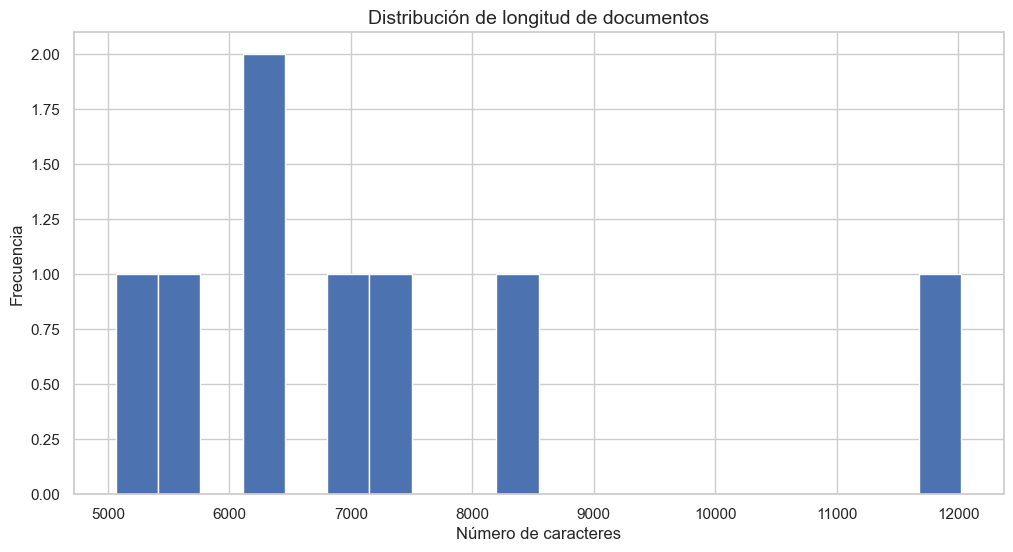

In [7]:
# =============================================
# EDA — Longitud de documentos
# =============================================
doc_lengths = []

for path in file_paths:
    try:
        with open(path, "r", encoding="utf-8") as f:
            content = f.read()
            doc_lengths.append(len(content))
    except:
        doc_lengths.append(0)

doc_lengths = np.array(doc_lengths)

# 📊 Estadísticas
print("📊 Estadísticas de longitud (en caracteres):\n")

print(f"Total documentos: {len(doc_lengths)}")
print(f"Media: {doc_lengths.mean():.2f}")
print(f"Mediana: {np.median(doc_lengths):.2f}")
print(f"Mínimo: {doc_lengths.min()}")
print(f"Máximo: {doc_lengths.max()}")

# 📈 Visualización
plt.figure()
plt.hist(doc_lengths, bins=20)
plt.title("Distribución de longitud de documentos")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.show()

In [8]:
# =============================================
# EDA — Calidad del texto
# =============================================

import re
import numpy as np

empty_docs = 0
short_docs = 0
noisy_docs = 0

noise_ratios = []

for path in file_paths:
    try:
        with open(path, "r", encoding="utf-8") as f:
            content = f.read()
            
            # 🔹 Documento vacío
            if len(content.strip()) == 0:
                empty_docs += 1
                continue
            
            # 🔹 Documento muy corto
            if len(content) < 50:
                short_docs += 1
            
            # 🔹 Medir ruido (caracteres no alfanuméricos)
            total_chars = len(content)
            clean_chars = len(re.findall(r"[a-zA-Z0-9\s]", content))
            
            noise_ratio = 1 - (clean_chars / total_chars)
            noise_ratios.append(noise_ratio)
            
            # 🔹 Documento con mucho ruido
            if noise_ratio > 0.3:
                noisy_docs += 1

    except:
        empty_docs += 1

noise_ratios = np.array(noise_ratios)

# 📊 Resultados
print("📊 Calidad del texto:\n")

print(f"Documentos vacíos: {empty_docs}")
print(f"Documentos muy cortos (<50 chars): {short_docs}")
print(f"Documentos con alto ruido (>30%): {noisy_docs}")

if len(noise_ratios) > 0:
    print(f"\nRuido promedio: {noise_ratios.mean():.2f}")
    print(f"Ruido máximo: {noise_ratios.max():.2f}")

📊 Calidad del texto:

Documentos vacíos: 0
Documentos muy cortos (<50 chars): 0
Documentos con alto ruido (>30%): 0

Ruido promedio: 0.06
Ruido máximo: 0.09


📊 Percentiles de longitud (caracteres):

P25: 6076
P50 (mediana): 6738
P75: 7671
P90: 9404
P95: 10715


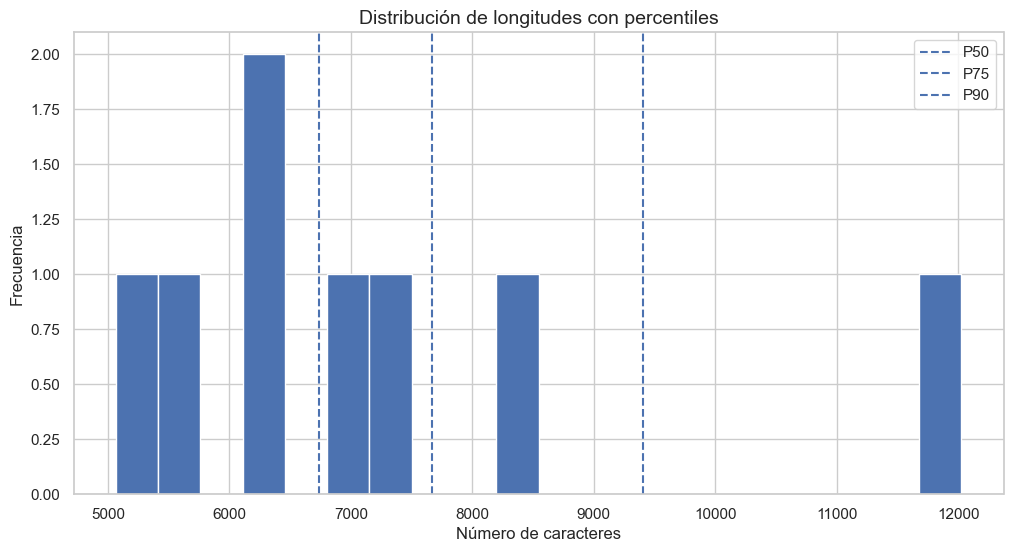


Documentos considerados outliers (>P95): 1


In [9]:
# =============================================
# EDA — Distribución avanzada de longitudes
# =============================================

import numpy as np
import matplotlib.pyplot as plt

# Reutilizamos doc_lengths del paso anterior
# (si no existe, lo recalculamos por seguridad)

doc_lengths = []

for path in file_paths:
    try:
        with open(path, "r", encoding="utf-8") as f:
            content = f.read()
            doc_lengths.append(len(content))
    except:
        doc_lengths.append(0)

doc_lengths = np.array(doc_lengths)

# 📊 Percentiles
p25 = np.percentile(doc_lengths, 25)
p50 = np.percentile(doc_lengths, 50)
p75 = np.percentile(doc_lengths, 75)
p90 = np.percentile(doc_lengths, 90)
p95 = np.percentile(doc_lengths, 95)

print("📊 Percentiles de longitud (caracteres):\n")
print(f"P25: {p25:.0f}")
print(f"P50 (mediana): {p50:.0f}")
print(f"P75: {p75:.0f}")
print(f"P90: {p90:.0f}")
print(f"P95: {p95:.0f}")

# 📈 Visualización con percentiles
plt.figure()
plt.hist(doc_lengths, bins=20)

plt.axvline(p50, linestyle='--', label='P50')
plt.axvline(p75, linestyle='--', label='P75')
plt.axvline(p90, linestyle='--', label='P90')

plt.title("Distribución de longitudes con percentiles")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.legend()

plt.show()

# 🔍 Detección de outliers (muy largos)
outliers = doc_lengths[doc_lengths > p95]

print(f"\nDocumentos considerados outliers (>P95): {len(outliers)}")

📊 Palabras más frecuentes:

inflation: 166
policy: 65
growth: 61
source: 56
financial: 54
monetary: 51
definition: 51
example: 51
price: 49
energy: 45
tightening: 40
demand: 38
markets: 38
market: 37
bank: 37


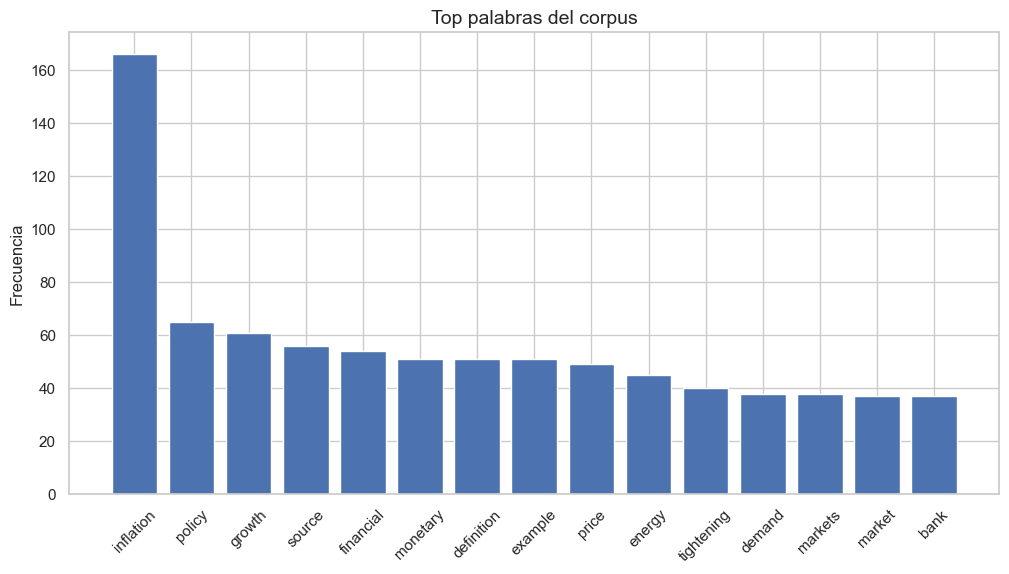

In [10]:
# =============================================
# EDA — Temática del corpus
# =============================================

import re
from collections import Counter
import matplotlib.pyplot as plt

all_text = ""

for path in file_paths:
    try:
        with open(path, "r", encoding="utf-8") as f:
            content = f.read().lower()
            all_text += " " + content
    except:
        continue

# 🔹 Limpieza básica
all_text = re.sub(r"[^a-zA-Záéíóúüñ\s]", " ", all_text)
words = all_text.split()

# 🔹 Stopwords básicas (mínimas, sin nltk)
stopwords = set([
    "the","and","of","to","in","a","is","for","on","with","as","by","at","an",
    "this","that","it","from","are","be","or","was","but","not","have",
    "el","la","los","las","de","y","en","un","una","es","con","por","para","del","se"
])

filtered_words = [w for w in words if w not in stopwords and len(w) > 3]

# 🔹 Frecuencias
word_counts = Counter(filtered_words)
top_words = word_counts.most_common(15)

# 📊 Mostrar resultados
print("📊 Palabras más frecuentes:\n")
for word, count in top_words:
    print(f"{word}: {count}")

# 📈 Visualización
words_plot = [w for w, _ in top_words]
counts_plot = [c for _, c in top_words]

plt.figure()
plt.bar(words_plot, counts_plot)
plt.title("Top palabras del corpus")
plt.xticks(rotation=45)
plt.ylabel("Frecuencia")
plt.show()